# House Price Prediction using Random Forest Regressor

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Loading cleaned dataset
df = pd.read_csv('Price_Conversion_cleaned_and_Proper.csv')

# Define Features (X) and Target (y)
X = df.drop(['price_lakh', 'log_price'], axis=1)
y = df['log_price']

# Training and Testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and Train the Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Metrics Calculation
mse = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Random Forest Regressor Metrics")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score (Train): {r2_train:.4f}")
print(f"R2 Score (Test): {r2_test:.4f}")

# Converting log predictions back to actual house prices (Lakhs)
actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(y_test_pred)

comparison_df = pd.DataFrame({'Actual Price (Lakhs)': actual_prices, 'Predicted Price (Lakhs)': predicted_prices})
print("\nSample Predicted House Prices")
print(comparison_df.head(10))

Random Forest Regressor Metrics
Mean Squared Error: 0.0001
R2 Score (Train): 1.0000
R2 Score (Test): 0.9998

Sample Predicted House Prices
       Actual Price (Lakhs)  Predicted Price (Lakhs)
19893                 29.50                30.943088
36271                 59.00                59.000000
43781                100.00               100.019806
27999                 86.87                86.518573
21025                177.00               177.491076
6067                  24.05                23.718718
8440                  78.00                77.969243
31104                124.00               124.242932
4850                  78.90                78.602995
11708                 80.00                79.692878


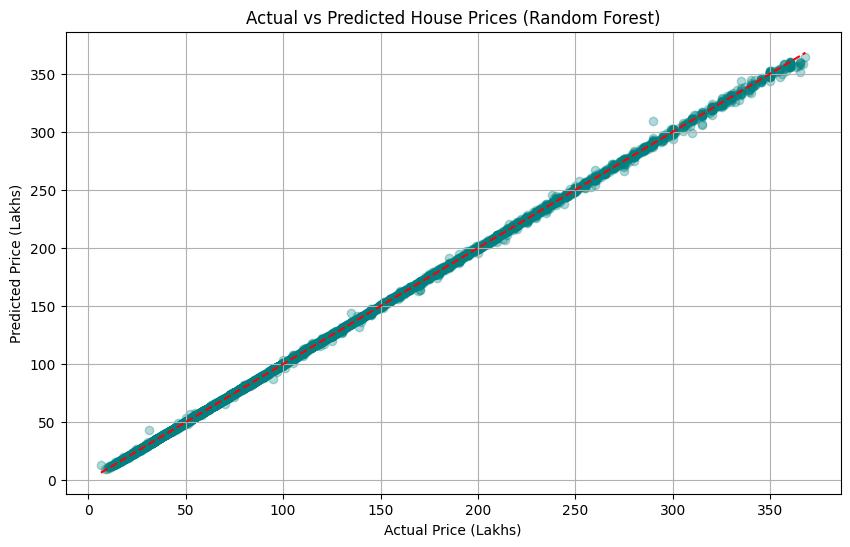

In [2]:
# Visualization: Actual vs Predicted Prices
plt.figure(figsize=(10, 6))
plt.scatter(actual_prices, predicted_prices, alpha=0.3, color='teal')
plt.plot([actual_prices.min(), actual_prices.max()], [actual_prices.min(), actual_prices.max()], 'r--')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted House Prices (Random Forest)')
plt.grid(True)
plt.show()